# World Cup Score Probability Model: Step 1 - Data Preparation
This notebook prepares historical international football data for a statistical predictive model (e.g., Poisson Regression or Bayesian Hierarchical Model). 

**Data Source:** Download the `results.csv` dataset from Kaggle (Search: "International football results from 1872 to [Current Year]" by Mart Jürisoo) and place it in the same directory as this notebook.

In [1]:
import pandas as pd
import numpy as np
import os
import requests
from pathlib import Path

# Set pandas display options to easily inspect our data later
pd.set_option('display.max_columns', None)
# 1. Define the URL for the raw dataset
# This points directly to the author's continuous updates on GitHub, bypassing Kaggle API limits
dataset_url = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"

# 2. Set up the directory structure
# This creates a 'data' folder in your current working directory if it doesn't already exist
data_dir = Path("data")
data_dir.mkdir(parents=True, exist_ok=True)

# Define the exact path where the file will be saved
file_path = data_dir / "results.csv"

# 3. Download and save the dataset
print("Downloading dataset...")
response = requests.get(dataset_url)

# Check if the download was successful
if response.status_code == 200:
    with open(file_path, 'wb') as file:
        file.write(response.content)
    print(f"Success! Dataset saved to: {file_path.absolute()}")
else:
    print(f"Failed to download the dataset. HTTP Status Code: {response.status_code}")

Success! Dataset saved to: /Users/davidpardo/Programming/world-cup-scores/data/results.csv


## 1. Load and Filter the Data
Football has changed drastically over the decades. Matches played in the 1930s or 1950s will introduce noise rather than signal. We will filter the dataset to only include matches from the last 50 years.

In [2]:
from src.data import prepare_matches

data_config = {"years": 50, "exclude_friendlies": True}
arrays = prepare_matches(data_config, file_path)

df = arrays.df
home_team_array = arrays.home_team_array
away_team_array = arrays.away_team_array
home_goals_array = arrays.home_goals_array
away_goals_array = arrays.away_goals_array
team_to_id = arrays.team_to_id
id_to_team = arrays.id_to_team
all_teams = np.array(sorted(team_to_id.keys()))
num_teams = arrays.num_teams

print(f"Matches: {arrays.n_matches} (dropped {arrays.n_dropped_missing_scores} with missing scores)")
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1906-08-15,Uruguay,Argentina,0.0,2.0,Copa Lipton,Montevideo,Uruguay,False
1,1906-10-21,Argentina,Uruguay,2.0,1.0,Copa Newton,Buenos Aires,Argentina,False
2,1907-02-16,England,Northern Ireland,1.0,0.0,British Home Championship,Liverpool,England,False
3,1907-02-23,Northern Ireland,Wales,2.0,3.0,British Home Championship,Belfast,Ireland,False
4,1907-03-04,Wales,Scotland,1.0,0.0,British Home Championship,Wrexham,Wales,False


## 2. Create Numerical IDs for Teams
Statistical models cannot perform math on strings like "Brazil" or "Japan". We need to map every unique team name to a specific integer index.

In [3]:
# Team IDs were created in the load step (see src/data.py)
print(f"Total unique teams registered: {num_teams}")

Total unique teams registered: 313


## 3. Extract the Modeling Arrays
Most modeling libraries (like PyMC or standard Scipy optimization) require clean 1D arrays of our parameters and outcomes. We will extract the exact arrays needed to build our Poisson distributions.

In [4]:
# Extract the team ID arrays
home_team_array = df['home_team_id'].values
away_team_array = df['away_team_id'].values

# Extract the observed outcome arrays (goals scored)
home_goals_array = df['home_score'].values
away_goals_array = df['away_score'].values

# Check the shapes to ensure everything aligns perfectly
print(f"Home Teams Array Shape: {home_team_array.shape}")
print(f"Away Teams Array Shape: {away_team_array.shape}")
print(f"Home Goals Array Shape: {home_goals_array.shape}")
print(f"Away Goals Array Shape: {away_goals_array.shape}")

Home Teams Array Shape: (30934,)
Away Teams Array Shape: (30934,)
Home Goals Array Shape: (30934,)
Away Goals Array Shape: (30934,)


## 4. Sanity Check
Let's look at a random match to ensure our ID mapping and goal extractions line up perfectly with the original data.

In [5]:
# Pick a random index
test_idx = 1000 

home_name = id_to_team[home_team_array[test_idx]]
away_name = id_to_team[away_team_array[test_idx]]
home_g = home_goals_array[test_idx]
away_g = away_goals_array[test_idx]
date = df['date'].iloc[test_idx].strftime('%Y-%m-%d')

print(f"Match at index {test_idx}:")
print(f"Date: {date}")
print(f"{home_name} (ID: {home_team_array[test_idx]}) {home_g} - {away_g} {away_name} (ID: {away_team_array[test_idx]})")

Match at index 1000:
Date: 1943-07-10
Paraguay (ID: 207) 2.0 - 5.0 Argentina (ID: 12)


## 5. Building the Bayesian Poisson Model (PyMC)
We will now use PyMC to build our probabilistic model. We are assigning an `attack` and `defense` parameter to every single team, plus a `home_advantage` parameter to account for the historical edge home teams have (even though World Cups are mostly neutral, this balances our historical training data).

**The Math:**
Expected Home Goals ($\lambda_{home}$) = $\exp(\text{Home Advantage} + \text{Home Attack} - \text{Away Defense})$
Expected Away Goals ($\lambda_{away}$) = $\exp(\text{Away Attack} - \text{Home Defense})$

In [8]:
# macOS fix: configure PyTensor C compiler before importing PyMC
import pytensor_macos

import pymc as pm
import arviz as az
import scipy.stats as stats
import matplotlib.pyplot as plt

from src.models import build_poisson_model

model_config = {
    "model": {
        "home_advantage": True,
        "attack_sigma": 1.5,
        "defense_sigma": 1.5,
    },
    "sample": {
        "draws": 2000,
        "tune": 1000,
        "chains": 4,
        "cores": 2,
        "target_accept": 0.9,
    },
}

basic_poisson_model = build_poisson_model(model_config, arrays)

print("Starting MCMC Sampling. This may take a few minutes...")
trace = pm.sample(model=basic_poisson_model, **model_config["sample"])
trace = pm.compute_log_likelihood(trace, model=basic_poisson_model)
print("Sampling complete!")

/Users/davidpardo/Programming/world-cup-scores/.venv/lib/python3.12/site-packages/pymc/model/core.py:1323: RuntimeWarning: invalid value encountered in cast
  data = convert_observed_data(data).astype(rv_var.dtype)
/Users/davidpardo/Programming/world-cup-scores/.venv/lib/python3.12/site-packages/pymc/model/core.py:1337: ImputationWarning: Data in home_goals contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
/Users/davidpardo/Programming/world-cup-scores/.venv/lib/python3.12/site-packages/pymc/model/core.py:1323: RuntimeWarning: invalid value encountered in cast
  data = convert_observed_data(data).astype(rv_var.dtype)
/Users/davidpardo/Programming/world-cup-scores/.venv/lib/python3.12/site-packages/pymc/model/core.py:1337: ImputationWarning: Data in away_goals contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning

Starting MCMC Sampling. This may take a few minutes...


Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>NUTS: [attack, defense, home_advantage]
>CompoundStep
>>Metropolis: [home_goals_unobserved]
>>Metropolis: [away_goals_unobserved]


/Users/davidpardo/Programming/world-cup-scores/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 721 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Sampling complete!


## 6. Inspecting the Posteriors
The MCMC algorithm has generated thousands of plausible values for every team's strength. Let's extract those distributions and look at a few top teams to see how the model rates them.

AttributeError: module 'arviz' has no attribute 'plot_kde'

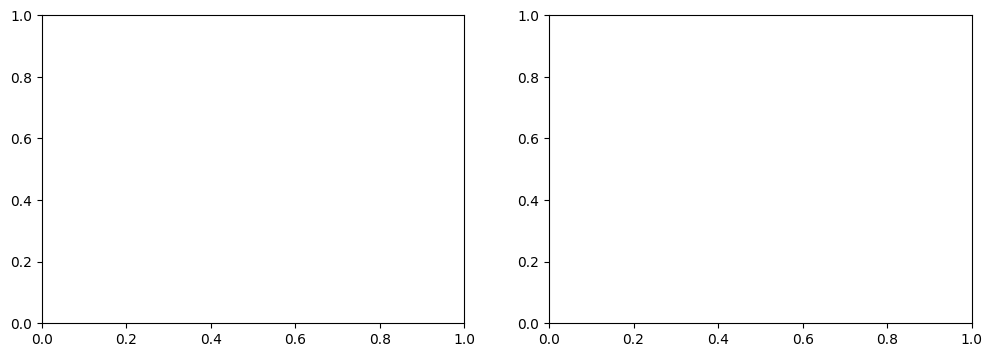

In [9]:
# Extract the posterior samples for attack and defense
posterior_attack = trace.posterior["attack"].values.reshape(-1, num_teams)
posterior_defense = trace.posterior["defense"].values.reshape(-1, num_teams)

def plot_kde_1d(samples, ax, alpha=0.5):
    """KDE on a matplotlib axis (replaces removed arviz.plot_kde in ArviZ 1.x)."""
    kde = stats.gaussian_kde(samples)
    x = np.linspace(samples.min(), samples.max(), 200)
    y = kde(x)
    ax.fill_between(x, y, alpha=alpha)
    ax.plot(x, y)

def plot_team_posterior(team_name):
    team_id = team_to_id[team_name]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot Attack
    plot_kde_1d(posterior_attack[:, team_id], ax=axes[0], alpha=0.5)
    axes[0].set_title(f"{team_name} - Attack Strength (Higher is better)")
    axes[0].axvline(0, color='red', linestyle='--') # Baseline
    
    # Plot Defense
    plot_kde_1d(posterior_defense[:, team_id], ax=axes[1], alpha=0.5)
    axes[1].set_title(f"{team_name} - Defense Strength (Higher is better at conceding)")
    axes[1].axvline(0, color='red', linestyle='--') # Baseline
    
    plt.tight_layout()
    plt.show()

# Feel free to change these names to any team in the id_to_team dictionary
plot_team_posterior("Brazil")
plot_team_posterior("France")

## 7. Predicting a Match Score (The Probability Matrix)
To predict a future match (e.g., in a World Cup), we take the thousands of simulated attack and defense parameters from our trace, calculate the expected goals for both teams, and generate a matrix of exact score probabilities using the Poisson probability mass function.

In [10]:
def predict_match(home_team, away_team, max_goals=5, neutral_venue=True):
    home_id = team_to_id[home_team]
    away_id = team_to_id[away_team]
    
    # Get all posterior samples for these specific teams
    h_attack = posterior_attack[:, home_id]
    h_defense = posterior_defense[:, home_id]
    a_attack = posterior_attack[:, away_id]
    a_defense = posterior_defense[:, away_id]
    
    # Get home advantage samples (set to 0 if playing at a neutral World Cup venue)
    h_adv = trace.posterior["home_advantage"].values.flatten()
    if neutral_venue:
        h_adv = np.zeros_like(h_adv)
        
    # Calculate Expected Goals (Lambda) across all MCMC samples
    home_lambda = np.exp(h_adv + h_attack - a_defense)
    away_lambda = np.exp(a_attack - h_defense)
    
    # Average the lambdas to get the final point estimate for Expected Goals
    mean_home_lambda = home_lambda.mean()
    mean_away_lambda = away_lambda.mean()
    
    # Generate the Probability Matrix
    prob_matrix = np.zeros((max_goals+1, max_goals+1))
    
    for i in range(max_goals+1):
        for j in range(max_goals+1):
            # Probability of home scoring 'i' goals * away scoring 'j' goals
            prob_home = stats.poisson.pmf(i, mean_home_lambda)
            prob_away = stats.poisson.pmf(j, mean_away_lambda)
            prob_matrix[i, j] = prob_home * prob_away
            
    # Calculate Win / Draw / Loss aggregates
    home_win = np.tril(prob_matrix, -1).sum()
    draw = np.trace(prob_matrix)
    away_win = np.triu(prob_matrix, 1).sum()
    
    # Print the results nicely
    print(f"--- PREDICTION: {home_team} vs {away_team} ---")
    print(f"Expected Goals: {home_team} {mean_home_lambda:.2f} - {mean_away_lambda:.2f} {away_team}\n")
    
    print(f"{home_team} Win: {home_win*100:.1f}%")
    print(f"Draw: {draw*100:.1f}%")
    print(f"{away_team} Win: {away_win*100:.1f}%\n")
    
    print("Exact Score Probabilities (Top 5):")
    
    # Flatten and sort the matrix to find the most likely scores
    flat_matrix = prob_matrix.flatten()
    top_indices = flat_matrix.argsort()[-5:][::-1]
    
    for idx in top_indices:
        h_goals = idx // (max_goals + 1)
        a_goals = idx % (max_goals + 1)
        print(f"{h_goals} - {a_goals} : {prob_matrix[h_goals, a_goals]*100:.1f}%")

# Test a prediction (e.g., a World Cup Final scenario on neutral ground)
predict_match("Argentina", "France", neutral_venue=True)

--- PREDICTION: Argentina vs France ---
Expected Goals: Argentina 1.16 - 1.10 France

Argentina Win: 36.9%
Draw: 28.7%
France Win: 34.2%

Exact Score Probabilities (Top 5):
1 - 1 : 13.3%
1 - 0 : 12.1%
0 - 1 : 11.5%
0 - 0 : 10.5%
2 - 1 : 7.7%


In [ ]:
# Run a tracked experiment (example: quick_test or baseline)
# from pathlib import Path
# from src.experiments import run_experiment
#
# run_id = run_experiment(Path("experiments/configs/baseline.yaml"))
# print(f"Logged to MLflow run_id={run_id}")
# Then: mlflow ui  OR  open notebooks/compare_experiments.ipynb